# Model Training v2

Ablation experiment: structural-only features to test for formula leakage.

In [1]:
# ================================
# IMPORTS
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
)
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Imports loaded.")

Imports loaded.


In [ ]:
df = pd.read_csv("../data/processed/building_level.csv")
print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:\n{df['accessibility_class'].value_counts()}")

FORMULA_LEAKY = [
    "step_free_entrance",
    "elevator_present",
    "handrails_present",
    "avg_clear_signage",
    "avg_high_contrast",
    "accessible_service_ratio",
    "accessible_critical_ratio",
]

OTHER_DROP = [
    "num_accessible_services",
    "num_accessible_critical",
    "ramps_present",
]

DROP_COLS = FORMULA_LEAKY + OTHER_DROP
TARGET = "accessibility_class"

feature_df = df.drop(columns=DROP_COLS + [TARGET])
y = df[TARGET]

print(f"\nStructural features kept ({feature_df.shape[1]}):")
print(list(feature_df.columns))
print(f"\nDropped ({len(DROP_COLS)}): {DROP_COLS}")

Dataset shape: (509, 20)

Class distribution:
accessibility_class
medium    229
high      180
low       100
Name: count, dtype: int64

Structural features kept (9):
['site_type', 'total_floors', 'total_services', 'num_critical_services', 'num_services_ground', 'num_services_upper', 'num_critical_upper', 'upper_service_ratio', 'critical_upper_ratio']

Dropped (10): ['step_free_entrance', 'elevator_present', 'handrails_present', 'avg_clear_signage', 'avg_high_contrast', 'accessible_service_ratio', 'accessible_critical_ratio', 'num_accessible_services', 'num_accessible_critical', 'ramps_present']


In [ ]:
categorical_features = ["site_type"]
numeric_features = [
    col for col in feature_df.columns if col not in categorical_features
]

print(f"Categorical: {categorical_features}")
print(f"Numeric ({len(numeric_features)}): {numeric_features}")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features),
    ]
)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = label_encoder.classes_
print(f"\nTarget classes: {class_names}")
print(f"Encoded mapping: {dict(zip(class_names, label_encoder.transform(class_names)))}")

X_train, X_test, y_train, y_test = train_test_split(
    feature_df, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"\nTrain: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")

Categorical: ['site_type']
Numeric (8): ['total_floors', 'total_services', 'num_critical_services', 'num_services_ground', 'num_services_upper', 'num_critical_upper', 'upper_service_ratio', 'critical_upper_ratio']

Target classes: ['high' 'low' 'medium']
Encoded mapping: {'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}

Train: 407  |  Test: 102


In [ ]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        solver="lbfgs", max_iter=1000,
        class_weight="balanced", random_state=42,
    )),
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

lr_acc = accuracy_score(y_test, y_pred_lr)
lr_f1  = f1_score(y_test, y_pred_lr, average="weighted")

print(f"Logistic Regression  --  Accuracy: {lr_acc:.4f}  |  F1 (weighted): {lr_f1:.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=class_names))

Logistic Regression  —  Accuracy: 0.3725  |  F1 (weighted): 0.3708

              precision    recall  f1-score   support

        high       0.40      0.44      0.42        36
         low       0.28      0.45      0.35        20
      medium       0.43      0.28      0.34        46

    accuracy                           0.37       102
   macro avg       0.37      0.39      0.37       102
weighted avg       0.39      0.37      0.37       102



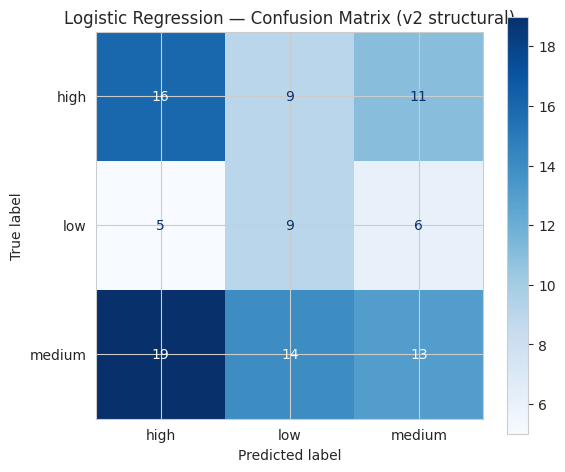

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, display_labels=class_names, ax=ax, cmap="Blues"
)
ax.set_title("Logistic Regression -- Confusion Matrix (v2 structural)")
plt.tight_layout()
plt.show()

In [ ]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
    )),
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1  = f1_score(y_test, y_pred_rf, average="weighted")

print(f"Random Forest  --  Accuracy: {rf_acc:.4f}  |  F1 (weighted): {rf_f1:.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=class_names))

Random Forest  —  Accuracy: 0.4020  |  F1 (weighted): 0.3966

              precision    recall  f1-score   support

        high       0.41      0.42      0.41        36
         low       0.27      0.20      0.23        20
      medium       0.44      0.48      0.46        46

    accuracy                           0.40       102
   macro avg       0.37      0.36      0.37       102
weighted avg       0.39      0.40      0.40       102



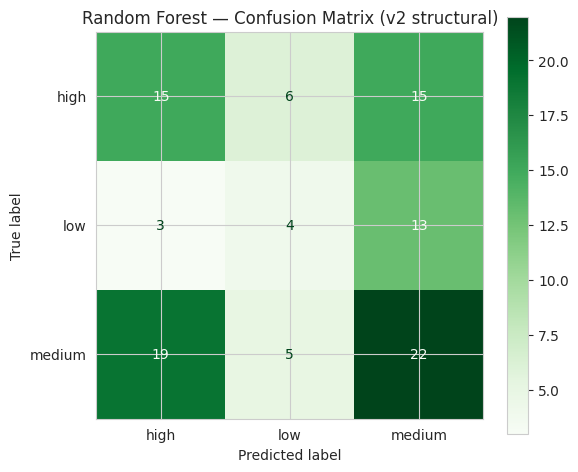

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, display_labels=class_names, ax=ax, cmap="Greens"
)
ax.set_title("Random Forest -- Confusion Matrix (v2 structural)")
plt.tight_layout()
plt.show()

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "f1_weighted"]

models = {
    "Logistic Regression": lr_pipeline,
    "Random Forest": rf_pipeline,
}

cv_results = {}
for name, model in models.items():
    scores = cross_validate(model, feature_df, y_encoded, cv=cv, scoring=scoring)
    cv_results[name] = scores
    acc_mean = scores["test_accuracy"].mean()
    acc_std  = scores["test_accuracy"].std()
    f1_mean  = scores["test_f1_weighted"].mean()
    f1_std   = scores["test_f1_weighted"].std()
    print(f"{name:25s}  Accuracy: {acc_mean:.4f} +/- {acc_std:.4f}  |  F1: {f1_mean:.4f} +/- {f1_std:.4f}")

cv_df = pd.DataFrame({
    name: {
        "CV Accuracy": f"{s['test_accuracy'].mean():.4f} +/- {s['test_accuracy'].std():.4f}",
        "CV F1 (weighted)": f"{s['test_f1_weighted'].mean():.4f} +/- {s['test_f1_weighted'].std():.4f}",
        "Test Accuracy": f"{accuracy_score(y_test, m.predict(X_test)):.4f}",
        "Test F1 (weighted)": f"{f1_score(y_test, m.predict(X_test), average='weighted'):.4f}",
    }
    for name, (s, m) in zip(cv_results.keys(), zip(cv_results.values(), models.values()))
})
print()
cv_df

Logistic Regression        Accuracy: 0.3851 ± 0.0407  |  F1: 0.3714 ± 0.0467
Random Forest              Accuracy: 0.3791 ± 0.0218  |  F1: 0.3820 ± 0.0230



,Logistic Regression,Random Forest
CV Accuracy,0.3851 ± 0.0407,0.3791 ± 0.0218
CV F1 (weighted),0.3714 ± 0.0467,0.3820 ± 0.0230
Test Accuracy,0.3725,0.4020
Test F1 (weighted),0.3708,0.3966


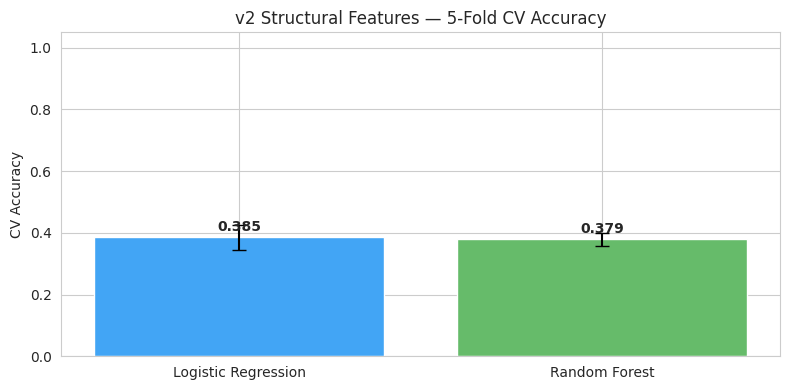

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
cv_acc = {n: s["test_accuracy"] for n, s in cv_results.items()}
positions = np.arange(len(cv_acc))
means = [v.mean() for v in cv_acc.values()]
stds  = [v.std() for v in cv_acc.values()]
bars = ax.bar(positions, means, yerr=stds, capsize=5,
              color=["#42A5F5", "#66BB6A"], edgecolor="white")
ax.set_xticks(positions)
ax.set_xticklabels(cv_acc.keys())
ax.set_ylabel("CV Accuracy")
ax.set_title("v2 Structural Features -- 5-Fold CV Accuracy")
ax.set_ylim(0, 1.05)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, m + 0.02, f"{m:.3f}",
            ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
cat_encoder = preprocessor.named_transformers_["cat"]
cat_feature_names = list(cat_encoder.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + cat_feature_names
print(f"Total features after encoding: {len(all_feature_names)}")
print(all_feature_names)

Total features after encoding: 11
['total_floors', 'total_services', 'num_critical_services', 'num_services_ground', 'num_services_upper', 'num_critical_upper', 'upper_service_ratio', 'critical_upper_ratio', 'site_type_hospital', 'site_type_library', 'site_type_school']


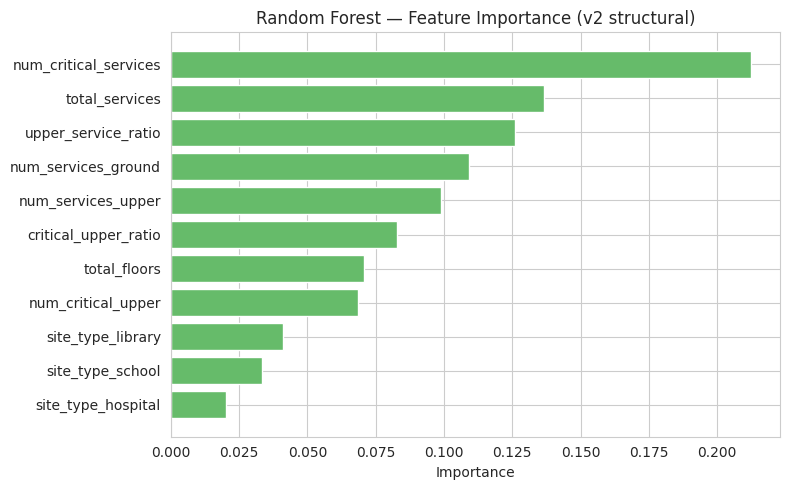

In [ ]:
rf_importances = rf_pipeline.named_steps["classifier"].feature_importances_
rf_imp_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": rf_importances,
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(rf_imp_df["feature"], rf_imp_df["importance"], color="#66BB6A")
ax.set_xlabel("Importance")
ax.set_title("Random Forest -- Feature Importance (v2 structural)")
plt.tight_layout()
plt.show()

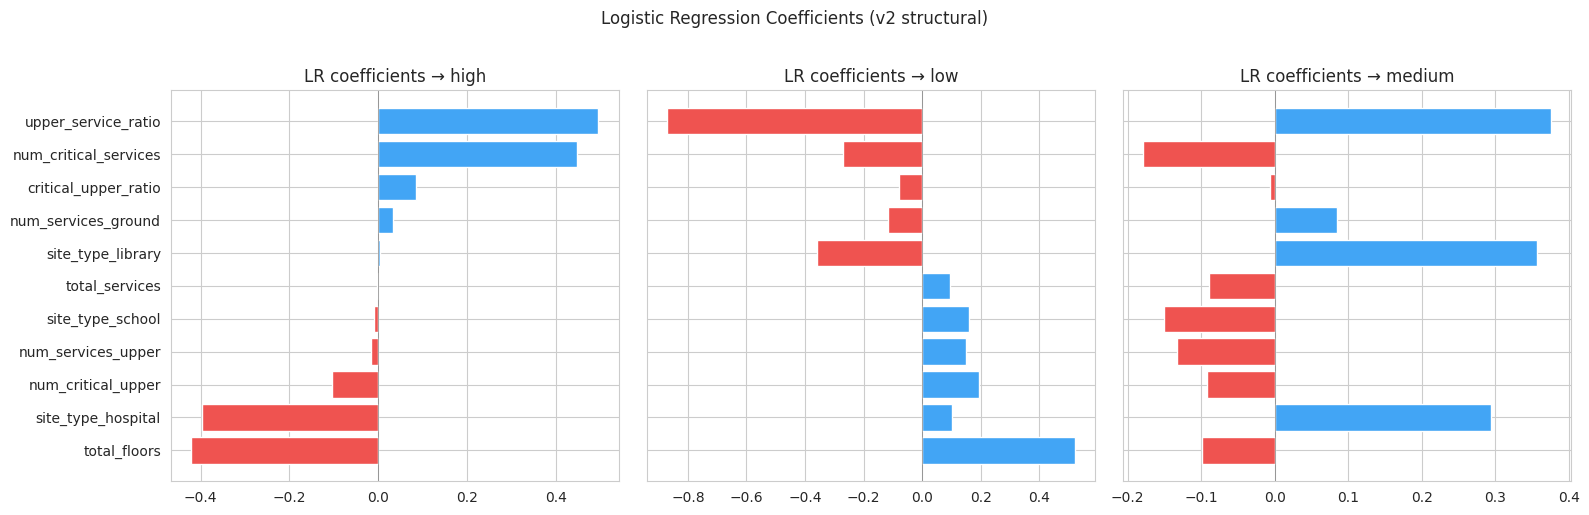

In [ ]:
lr_coefs = lr_pipeline.named_steps["classifier"].coef_
fig, axes = plt.subplots(1, len(class_names), figsize=(16, 5), sharey=True)
for i, (cls, ax) in enumerate(zip(class_names, axes)):
    coef_sorted = pd.Series(lr_coefs[i], index=all_feature_names).sort_values()
    colors = ["#EF5350" if v < 0 else "#42A5F5" for v in coef_sorted]
    ax.barh(coef_sorted.index, coef_sorted.values, color=colors)
    ax.set_title(f"LR coefficients -> {cls}")
    ax.axvline(0, color="grey", linewidth=0.5)
plt.suptitle("Logistic Regression Coefficients (v2 structural)", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
lr_results = {"pipeline": lr_pipeline, "acc": lr_acc, "f1": lr_f1,
              "cv_acc": cv_results["Logistic Regression"]["test_accuracy"].mean()}
rf_results = {"pipeline": rf_pipeline, "acc": rf_acc, "f1": rf_f1,
              "cv_acc": cv_results["Random Forest"]["test_accuracy"].mean()}

if rf_results["cv_acc"] > lr_results["cv_acc"]:
    best_name, best_pipeline = "Random Forest", rf_pipeline
else:
    best_name, best_pipeline = "Logistic Regression", lr_pipeline

print(f"Best model (by CV accuracy): {best_name}")

model_dir = "../models"
os.makedirs(model_dir, exist_ok=True)

model_path   = os.path.join(model_dir, "accessibility_model_v2.joblib")
encoder_path = os.path.join(model_dir, "label_encoder_v2.joblib")
meta_path    = os.path.join(model_dir, "model_metadata_v2.joblib")

joblib.dump(best_pipeline, model_path)
joblib.dump(label_encoder, encoder_path)

metadata = {
    "version": "v2_structural",
    "best_model": best_name,
    "features": list(feature_df.columns),
    "test_accuracy": accuracy_score(y_test, best_pipeline.predict(X_test)),
    "test_f1_weighted": f1_score(y_test, best_pipeline.predict(X_test), average="weighted"),
    "cv_accuracy_mean": cv_results[best_name]["test_accuracy"].mean(),
    "class_names": list(class_names),
    "dropped_formula_features": FORMULA_LEAKY,
}
joblib.dump(metadata, meta_path)

print(f"\nSaved to {model_dir}/:")
for f in [model_path, encoder_path, meta_path]:
    print(f"  {os.path.basename(f)}")
print(f"\nMetadata: {metadata}")

Best model (by CV accuracy): Logistic Regression

Saved to ../models/:
  • accessibility_model_v2.joblib
  • label_encoder_v2.joblib
  • model_metadata_v2.joblib

Metadata: {'version': 'v2_structural', 'best_model': 'Logistic Regression', 'features': ['site_type', 'total_floors', 'total_services', 'num_critical_services', 'num_services_ground', 'num_services_upper', 'num_critical_upper', 'upper_service_ratio', 'critical_upper_ratio'], 'test_accuracy': 0.37254901960784315, 'test_f1_weighted': 0.37076288005080577, 'cv_accuracy_mean': np.float64(0.38514851485148516), 'class_names': ['high', 'low', 'medium'], 'dropped_formula_features': ['step_free_entrance', 'elevator_present', 'handrails_present', 'avg_clear_signage', 'avg_high_contrast', 'accessible_service_ratio', 'accessible_critical_ratio']}
